# Biogas NPV simulation

Run the biogas electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_technology_npv,
)


In [2]:
TECHNOLOGY = 'biogas'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_electricity_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,biogas,1000000.0,5300.0,188.679245,188679.245283,5133.828805,288.261182,4.003700,2.517454,...,94070000.0,5.438890e+07,4.003700e+06,2.202773e+08,0.0,-1.845999e+08,-2.939209e+09,25000000.0,-117.568368,-0.000118
1,1,biogas,1000000.0,5300.0,188.679245,188679.245283,4164.114205,290.084482,3.991746,2.505914,...,94070000.0,5.473292e+07,3.991746e+06,2.192675e+08,0.0,-1.839222e+08,-2.749010e+09,25000000.0,-109.960392,-0.000110
2,2,biogas,1000000.0,5300.0,188.679245,188679.245283,5378.782380,204.303829,4.637170,2.577792,...,94070000.0,3.854789e+07,4.637170e+06,2.255568e+08,0.0,-1.746719e+08,-2.879448e+09,25000000.0,-115.177909,-0.000115
3,3,biogas,1000000.0,5300.0,188.679245,188679.245283,4912.183076,144.880242,4.193162,2.571169,...,94070000.0,2.733589e+07,4.193162e+06,2.249773e+08,0.0,-1.624364e+08,-2.660799e+09,25000000.0,-106.431962,-0.000106
4,4,biogas,1000000.0,5300.0,188.679245,188679.245283,3166.549245,246.674937,4.440968,2.573209,...,94070000.0,4.654244e+07,4.440968e+06,2.251558e+08,0.0,-1.820692e+08,-2.541010e+09,25000000.0,-101.640388,-0.000102


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-2615.216868,-104.608675
std,208.758971,8.350359
min,-3214.420459,-128.576818
5%,-2958.827526,-118.353101
50%,-2615.731663,-104.629267
95%,-2269.270941,-90.770838
max,-2040.216768,-81.608671


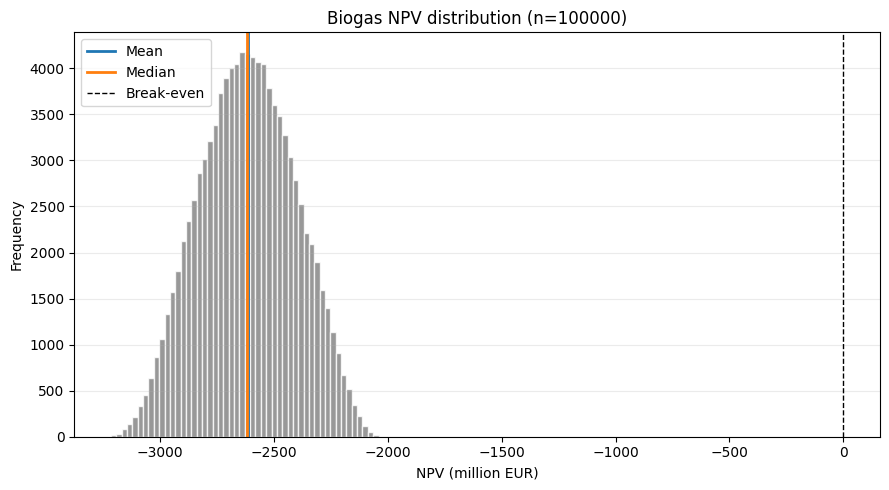

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


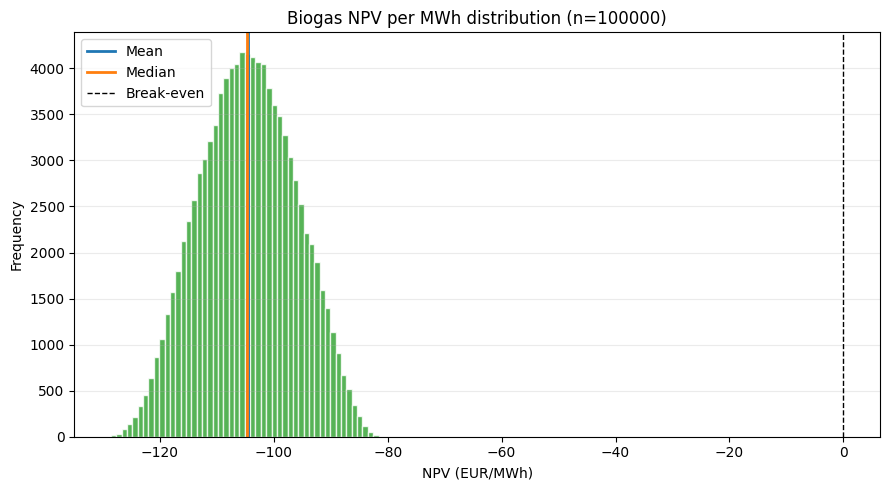

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur            94.070000
annual_fixed_opex_eur         37.105921
annual_variable_opex_eur       4.133955
annual_fuel_cost_eur         221.060258
annual_emissions_cost_eur      0.000000
annual_net_cash_flow_eur    -168.230134
Name: Mean annual value, million EUR, dtype: float64